## T09 - Resampling


Sofia Anaya Palafox

738594

Ingeniería Financiera

1. Using basic statistical properties of the variance, as well as single-
variable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1− α)Y ).

In [50]:
import sympy
from sympy import symbols

# Definir las variables
alpha, X, Y, sigma_X, sigma_Y, sigma_XY = symbols('alpha X Y sigma_X sigma_Y sigma_XY')

varianza = alpha**2 * sigma_X**2 + (1 - alpha)**2 * sigma_Y**2 + 2 * alpha * (1 - alpha) * sigma_XY

derivar = sympy.diff(varianza, alpha)
print("Derivar para alpha:")
print(derivar)

# Derivar
solucion = sympy.solve(derivar, alpha)
print("Solucion para alpha:")
print(solucion)

Derivar para alpha:
2*alpha*sigma_X**2 - 2*alpha*sigma_XY + 2*sigma_XY*(1 - alpha) + sigma_Y**2*(2*alpha - 2)
Solucion para alpha:
[(-sigma_XY + sigma_Y**2)/(sigma_X**2 - 2*sigma_XY + sigma_Y**2)]


2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.


(a) What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.


(b) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?


(c) Argue that the probability that the jth observation is not in the
bootstrap sample is (1− 1/n)n


(d) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?


(e) When n = 100, what is the probability that the jth observa-
tion is in the bootstrap sample?


(f) When n = 10, 000, what is the probability that the jth observa-
tion is in the bootstrap sample?


(g) Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.


(h) We will now investigate numerically the probability that a boot-
strap sample of size n = 100 contains the jth observation. Here
j = 4. We first create an array store with values that will subse-
quently be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we record
whether or not the fifth observation is contained in the bootstrap
sample.

**(a) Primera observación no es la j-ésima:**

P=(1/n)


 **(b) Segunda observación tampoco es la j-ésima: La probabilidad es la misma:**

P=1-(1/n)


**(c) Probabilidad de que la j-ésima no esté en la muestra:**

(1-(1/ n))**n

**(d) Para n = 5:**

(1-(1/5))**5 = .32768

1−0.32768=0.67232

**(e) Para n = 100:**

(1-(1/100))**100 = .3679

1-.3679 = .6321

**(f) Para n = 10,000:**

(1-(1/10000))**10000 = .3679


**(g)**

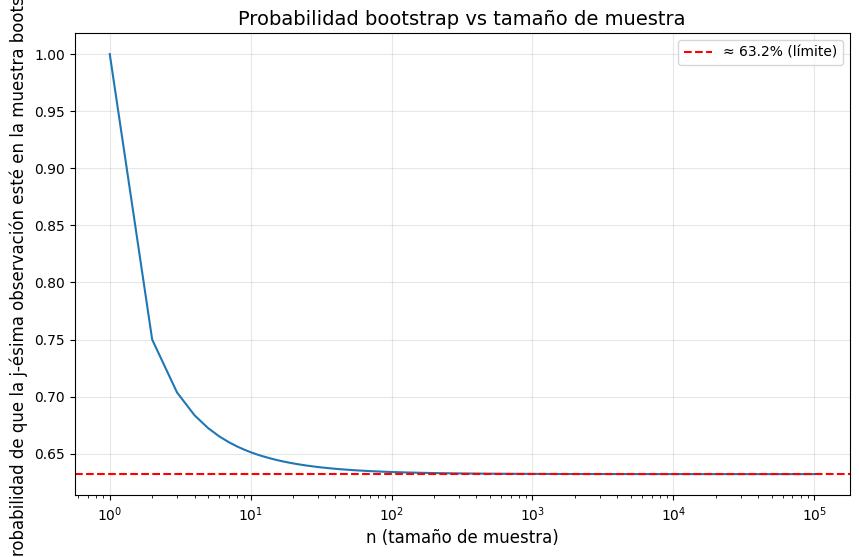

In [51]:
import numpy as np
import matplotlib.pyplot as plt

n_vals = np.arange(1, 100001)
prob_si_esta = 1 - (1 - 1/n_vals)**n_vals

plt.figure(figsize=(10,6))
plt.plot(n_vals, prob_si_esta)
plt.xscale('log')
plt.xlabel('n (tamaño de muestra)', fontsize=12)
plt.ylabel('Probabilidad de que la j-ésima observación esté en la muestra bootstrap', fontsize=12)
plt.title('Probabilidad bootstrap vs tamaño de muestra', fontsize=14)
plt.axhline(y=0.632, color='r', linestyle='--', label='≈ 63.2% (límite)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. **We now review k-fold cross-validation.**

**(a) Explain how k-fold cross-validation is implemented.**

k-fold cross-validation

(a) Cómo se implementa:

Se dividen los datos en k grupos (folds) de aproximadamente igual tamaño

Para i = 1 hasta k:

El fold i se usa como validación

Los otros k-1 folds se usan como entrenamiento

Se entrena el modelo y se evalúa en validación

El error final es el promedio de los k errorestrain-test split.

**(b) What are the advantages and disadvantages of k-fold cross-validation relative to:**

*Validación simple (validation set) vs. k-fold CV:*

Sesgo: La validación simple tiene mayor sesgo porque entrena con solo la mitad de los datos (aprox), mientras que k-fold CV entrena con más datos.

Varianza: La validación simple tiene mayor varianza porque el resultado cambia mucho dependiendo de cómo se dividan los datos. Con k-fold CV, al promediar k resultados, la estimación es mejor.

Costo: La validación simple es más barata (solo un entrenamiento), mientras que k-fold CV requiere k entrenamientos.


*LOOCV vs. k-fold CV:*

Sesgo: LOOCV tiene menor sesgo porque entrena con casi todos los datos, mientras que k-fold CV entrena con un poco menos.

Varianza: LOOCV tiene mayor varianza porque los n modelos entrenados son muy parecidos (comparten casi todos los datos), por lo que sus errores están correlacionados. El promedio de cosas muy correlacionadas tiene más varianza. Con k-fold CV (k < n), los modelos son más diferentes entre sí, dando menor varianza.

Costo: LOOCV es mucho más caro (n entrenamientos). Con k-fold CV solo haces k entrenamientos.

## 4. Suppose that we use some statistical learning method to make a pre-diction for the response Y for a particular value of the predictor X.


Carefully describe how we might estimate the standard deviation of
our prediction.

In [52]:
def estimar(modelo, X, y, X_nuevo, B=1000):

    predicciones = []
    n = len(X)

    for _ in range(B):
        # Muestrear con reemplazo
        idx = np.random.choice(n, n, replace=True)
        X_boot = X[idx]
        y_boot = y[idx]

        # Entrenar modelo
        modelo = clone(modelo)  # hacer una copia limpia
        modelo.fit(X_boot, y_boot)

        # Predecir
        pred = modelo.predict(X_nuevo)
        predicciones.append(pred)

    predicciones = np.array(predicciones)
    se = np.std(predicciones, axis=0)  # error estándar bootstrap
    return se

5. In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.
(a) Fit a logistic regression model that uses income and balance to
predict default.
(b) Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:
i. Split the sample set into a training set and a validation set.
ii. Fit a multiple logistic regression model using only the train-
ing observations.
iii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.
iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.
(c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Com-
ment on the results obtained.
(d) Now consider a logistic regression model that predicts the prob-
ability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the val-
idation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [54]:
import numpy as np
import pandas as pd
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Cargar datos
Default = load_data('Default')

# Crear variable binaria para default
Default['default_binaria'] = (Default['default'] == 'Yes').astype(int)

# (a) Modelo con income y balance
X = Default[['income', 'balance']]
y = Default['default_binaria']

# (b) Validación set approach
def validation_error(X, y, test_size=0.5, random_state=None):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    return error

# Un split
np.random.seed(42)
error1 = validation_error(X, y, random_state=42)
print(f"Error de validación (split 1): {error1:.4f}")

# (c) Tres splits diferentes
errores = []
for seed in [42, 123, 456]:
    err = validation_error(X, y, random_state=seed)
    errores.append(err)
    print(f"Seed {seed}: error = {err:.4f}")

print(f"Media de errores: {np.mean(errores):.4f}")
print(f"Desviación: {np.std(errores):.4f}")

# (d) Modelo con student dummy
Default['student_binary'] = (Default['student'] == 'Yes').astype(int)
X2 = Default[['income', 'balance', 'student_binary']]

error_student = validation_error(X2, y, random_state=42)
print(f"\nError incluyendo 'student': {error_student:.4f}")
print(f"Mejora respecto al modelo sin student: {error1 - error_student:.4f}")

Error de validación (split 1): 0.0258
Seed 42: error = 0.0258
Seed 123: error = 0.0256
Seed 456: error = 0.0266
Media de errores: 0.0260
Desviación: 0.0004

Error incluyendo 'student': 0.0256
Mejora respecto al modelo sin student: 0.0002


6. We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coeffi-
cients in two different ways: (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis.


(a) Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.


(b) Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.


(c) Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.


(d) Comment on the estimated standard errors obtained using the
sm.GLM() function and using the bootstrap.

In [55]:
from sklearn.linear_model import LogisticRegression

def boot_fn(D, idx):
    """Estima coeficientes de logística en muestra bootstrap"""
    D_boot = D.iloc[idx]
    X_boot = D_boot[['income', 'balance']]
    y_boot = (D_boot['default'] == 'Yes').astype(int)

    model = LogisticRegression()
    model.fit(X_boot, y_boot)
    return np.array([model.coef_[0,0], model.coef_[0,1]])  # [income_coef, balance_coef]

# Bootstrap con B=1000
B = 1000
rng = np.random.default_rng(0)
coeficientes = []

for _ in range(B):
    idx = rng.choice(len(Default), len(Default), replace=True)
    coefs = boot_fn(Default, idx)
    coeficientes.append(coefs)

coeficientes = np.array(coeficientes)

# Errores estándar bootstrap
se_income_boot = np.std(coeficientes[:, 0])
se_balance_boot = np.std(coeficientes[:, 1])

print(f"Error estándar bootstrap - income: {se_income_boot:.6f}")
print(f"Error estándar bootstrap - balance: {se_balance_boot:.6f}")

# Comparar con los de statsmodels (aproximadamente)
from statsmodels.discrete.discrete_model import Logit
import statsmodels.api as sm

X_sm = sm.add_constant(Default[['income', 'balance']])
y_sm = (Default['default'] == 'Yes').astype(int)
model_sm = Logit(y_sm, X_sm).fit(disp=0)
print(f"\nIncome - bootstrap: {se_income_boot:.6f} | statsmodels: {model_sm.bse[1]:.6f}")
print(f"Balance - bootstrap: {se_balance_boot:.6f} | statsmodels: {model_sm.bse[2]:.6f}")

Error estándar bootstrap - income: 0.000005
Error estándar bootstrap - balance: 0.000230

Income - bootstrap: 0.000005 | statsmodels: 0.000005
Balance - bootstrap: 0.000230 | statsmodels: 0.000227


/tmp/ipykernel_10295/1265484796.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nIncome - bootstrap: {se_income_boot:.6f} | statsmodels: {model_sm.bse[1]:.6f}")
/tmp/ipykernel_10295/1265484796.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Balance - bootstrap: {se_balance_boot:.6f} | statsmodels: {model_sm.bse[2]:.6f}")


7. In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).
(a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.
(b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.
(c) Use the model from (b) to predict the direction of the first obser-
vation. You can do this by predicting that the first observation
will go up if P (Direction = "Up"|Lag1, Lag2) > 0.5. Was this
observation correctly classified?
(d) Write a for loop from i = 1 to i= n, where n is the number of
observations in the data set, that performs each of the following
steps:
i. Fit a logistic regression model using all but the ith obser-
vation to predict Direction using Lag1 and Lag2.
ii. Compute the posterior probability of the market moving up
for the ith observation.
iii. Use the posterior probability for the ith observation in order
to predict whether or not the market moves up.
iv. Determine whether or not an error was made in predicting
the direction for the ith observation. If an error was made,
then indicate this as a 1, and otherwise indicate it as a 0.
(e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [56]:
Weekly = load_data('Weekly')
Weekly['Direction_binary'] = (Weekly['Direction'] == 'Up').astype(int)

n = len(Weekly)
errores_loocv = []

for i in range(n):  # i desde 0 hasta n-1
    # Training: todo menos observación i
    X_train = Weekly.drop(index=i)[['Lag1', 'Lag2']]
    y_train = Weekly.drop(index=i)['Direction_binary']

    # Test: solo observación i
    X_test = Weekly.iloc[[i]][['Lag1', 'Lag2']]
    y_test = Weekly.iloc[i]['Direction_binary']

    # Ajustar modelo
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Predecir
    y_pred = model.predict(X_test)[0]

    # Error
    error = 1 if y_pred != y_test else 0
    errores_loocv.append(error)

tasa_error_loocv = np.mean(errores_loocv)
print(f"Tasa de error LOOCV: {tasa_error_loocv:.4f}")

Tasa de error LOOCV: 0.4500


8. We will now perform cross-validation on a simulated data set.
(a) Generate a simulated data set as follows:
rng = np.random. default_rng (1)
x = rng.normal(size =100)
y = x - 2 * x**2 + rng.normal(size =100)
In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.
(b) Create a scatterplot of X against Y . Comment on what you find.
(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:
i. Y= β0 + β1X + ϵ
ii. Y= β0 + β1X + β2X2 + ϵ
iii. Y= β0 + β1X + β2X2 + β3X3 + ϵ
iv. Y= β0 + β1X + β2X2 + β3X3 + β4X4 + ϵ.
Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y.
(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?
(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.
(f) Comment on the statistical significance of the coefficient esti-
mates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

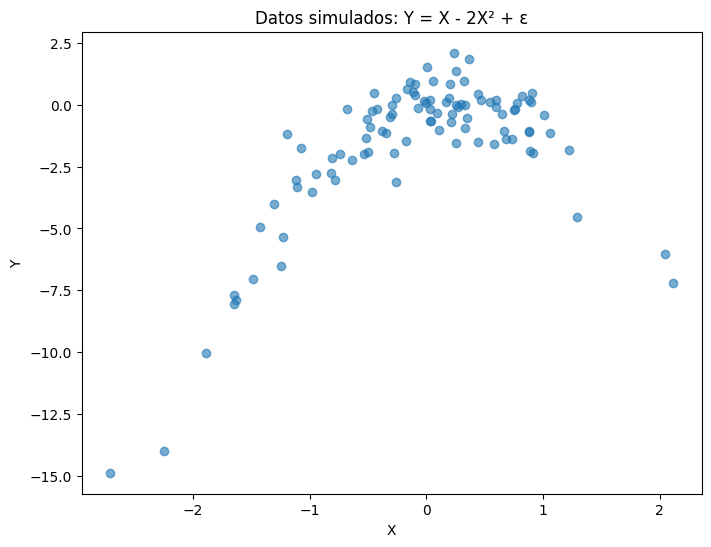

Grado 1: LOOCV MSE = 6.6330
Grado 2: LOOCV MSE = 1.1229
Grado 3: LOOCV MSE = 1.3018
Grado 4: LOOCV MSE = 1.3324

Mejor grado según LOOCV: 2
(Se espera grado 2, que es la verdadera relación)


In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# (a) Generar datos
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# (b) Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos simulados: Y = X - 2X² + ε')
plt.show()

# (c) LOOCV para diferentes polinomios (1 a 4)
grados = [1, 2, 3, 4]
errores_loocv = []

for d in grados:
    modelo = make_pipeline(PolynomialFeatures(d, include_bias=False),
                          LinearRegression())
    # LOOCV mediante cross_val_score con cv = n
    scores = cross_val_score(modelo, x.reshape(-1,1), y,
                            cv=len(x), scoring='neg_mean_squared_error')
    mse_loocv = -np.mean(scores)
    errores_loocv.append(mse_loocv)
    print(f"Grado {d}: LOOCV MSE = {mse_loocv:.4f}")

# (d) Con otra semilla
rng2 = np.random.default_rng(2)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

# (e) Mejor grado
mejor_grado = grados[np.argmin(errores_loocv)]
print(f"\nMejor grado según LOOCV: {mejor_grado}")
print("(Se espera grado 2, que es la verdadera relación)")

9. We will now consider the Boston housing data set, from the ISLP
library.
(a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimateˆ
µ.
(b) Provide an estimate of the standard error ofˆ
µ. Interpret this
result.
Hint: We can compute the standard error of the sample mean by
dividing the sample standard deviation by the square root of the
number of observations.
(c) Now estimate the standard error ofˆ
µ using the bootstrap. How
does this compare to your answer from (b)?
(d) Based on your bootstrap estimate from (c), provide a 95 % con-
fidence interval for the mean of medv. Compare it to the results
obtained by using Boston['medv'].std() and the two standard
error rule (3.9).
Hint: You can approximate a 95 % confidence interval using the
formula [ˆ µ− 2SE(ˆ µ),
ˆ
µ + 2SE(ˆ µ)].
(e) Based on this data set, provide an estimate,ˆ
µmed, for the median
value of medv in the population.
(f) We now would like to estimate the standard error ofˆ
µmed. Unfor-
tunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.
(g) Based on this data set, provide an estimate for the tenth per-
centile of medv in Boston census tracts. Call this quantityˆ
µ0.1.
(You can use the np.percentile() function.) (h) Use the bootstrap to estimate the standard error ofˆ
µ0.1. Com-
ment on your findings.

### 9. Boston Housing Data Set Analysis

In [59]:
Boston = load_data('Boston')
medv = Boston['medv']

# (a) Media poblacional estimada
mu_hat = np.mean(medv)
print(f"Media estimada de medv: ${mu_hat*1000:.0f}")

# (b) Error estándar teórico
se_teorico = np.std(medv, ddof=1) / np.sqrt(len(medv))
print(f"Error estándar teórico: {se_teorico:.4f}")

# (c) Bootstrap SE
def boot_se(data, func, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    estadisticos = []
    n = len(data)
    for _ in range(B):
        muestra = rng.choice(data, n, replace=True)
        estadisticos.append(func(muestra))
    return np.std(estadisticos)

se_bootstrap = boot_se(medv, np.mean, B=1000)
print(f"Error estándar bootstrap: {se_bootstrap:.4f}")

# (d) Intervalo de confianza 95%
ic_inf = mu_hat - 2 * se_bootstrap
ic_sup = mu_hat + 2 * se_bootstrap
print(f"IC 95% bootstrap: [{ic_inf:.2f}, {ic_sup:.2f}]")

# (e) Mediana
mediana_hat = np.median(medv)
print(f"\nMediana estimada: ${mediana_hat*1000:.0f}")

# (f) Bootstrap para mediana
se_mediana = boot_se(medv, np.median, B=1000)
print(f"Error estándar de la mediana (bootstrap): {se_mediana:.4f}")

# (g) Percentil 10
percentil10_hat = np.percentile(medv, 10)
print(f"Percentil 10 estimado: ${percentil10_hat*1000:.0f}")

# (h) Bootstrap para percentil 10
se_percentil10 = boot_se(medv, lambda x: np.percentile(x, 10), B=1000)
print(f"Error estándar del percentil 10 (bootstrap): {se_percentil10:.4f}")

Media estimada de medv: $22533
Error estándar teórico: 0.4089
Error estándar bootstrap: 0.4125
IC 95% bootstrap: [21.71, 23.36]

Mediana estimada: $21200
Error estándar de la mediana (bootstrap): 0.3694
Percentil 10 estimado: $12750
Error estándar del percentil 10 (bootstrap): 0.5035
